# Shallow moments in 2-D

Shallow moments in 1-D recover the vertical structure of a 2-D flow; in 2-D
they are essentially our 3-D model. The dimensionality is set by the mesh.

We write our own bed-drag closure, inject it into `SME`, and read the vertical
velocity profile back out.

## 1. A closure of our own

A `Closure` declares what it `closes` and what it `requires`. For a bottom
closure the framework asks for the **traction vector** in the local frame
$\{n, t_\alpha\}$ — one tangential entry per horizontal direction, coupled
through $|u_t|$. Chézy-type quadratic drag, $\tau_b = \rho\,C_d\,|u_b|\,u_b$:

In [1]:
import sympy as sp
from zoomy_core.model.models.closures import Closure


class ChezyBed(Closure):
    """Quadratic Chezy bed drag:  tau_b = rho * C_d * |u_b| u_b."""

    closes = "bottom"
    requires = ("u",)

    def register(self, m):
        m.parameter("C_d", 2.5e-3)

    def traction(self, s):
        speed = sp.sqrt(sum(ut ** 2 for ut in s.u_tangent))
        return {
            "normal": None,
            "tangent": [s.par.rho * s.par.C_d * speed * ut for ut in s.u_tangent],
        }

## 2. Build the model

No subclass — closures and parameters are arguments. Both coefficients matter:
`nu` (bulk friction) is what shapes the profile, and the bed drag `C_d` is what
initiates the shear for it to act on. With either at zero there is no profile
to see. `level=2` carries two moments beyond the depth average, enough for the
profile to have curvature rather than just a tilt.

In [2]:
import numpy as np

from zoomy_core.model.models import SME, Newtonian, StressFree
from zoomy_core.model.boundary_conditions import Extrapolation
from zoomy_core.model.initial_conditions import RP2d, Constant
from zoomy_core.systemmodel import SystemModel

sm = SystemModel.from_model(SME(
    level=2, dimension=3, quadrature_order=8,
    parameters={"nu": 0.1, "C_d": 0.5},
    closures=[Newtonian(), ChezyBed(), StressFree()],
    boundary_conditions=[Extrapolation(t)
                         for t in ("left", "right", "bottom", "top")],
))

high = np.zeros(len(sm.state)); high[1] = 2.0
low = np.zeros(len(sm.state)); low[1] = 1.0
sm.initial_conditions = RP2d(high=lambda n, h=high: h, low=lambda n, l=low: l,
                             jump_position_x=0.5, jump_position_y=0.5)
sm.aux_initial_conditions = Constant(constants=lambda n: np.zeros(n))

sm.describe()

**SystemModel** — 8 equations, 2 spatial dimensions

**Parameters:** $g = 9.81$, $\rho = 1.0$, $\nu = 0.1$, $\lambda_{s} = 0.0$, $e_{x} = 0.0$, $C_{d} = 0.5$

**System form:**

$$M(Q)\,\partial_t Q + \nabla\cdot\!\big(F(Q) + P(Q)\big) + \sum_{d} B_{d}(Q)\,\partial_{d} Q - \nabla\cdot\!\big(A(Q)\,\nabla Q\big) - S(Q) = 0$$

**State $Q$:**

$$
\left[\begin{matrix}b\\h\\q_{x 0}\\q_{x 1}\\q_{x 2}\\q_{y 0}\\q_{y 1}\\q_{y 2}\end{matrix}\right]
$$

**Auxiliary $Q_{aux}$:**

$$
\left[\begin{matrix}dq_{x1dx}\\dq_{y1dy}\\dq_{x2dx}\\dq_{y2dy}\\dq_{x0dx}\\dhdx\\dq_{y0dy}\\dhdy\\dbdx\\dbdy\end{matrix}\right]
$$

**Mass matrix $M$:**

$$
\left[\begin{matrix}1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 1 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 1\end{matrix}\right]
$$

**Flux $F$:**

$$
\left[\begin{matrix}0 & 0\\q_{x 0} & q_{y 0}\\\frac{q_{x 0}^{2}}{h} + \frac{q_{x 1}^{2}}{3 h} + \frac{q_{x 2}^{2}}{5 h} & \frac{q_{x 0} q_{y 0}}{h} + \frac{q_{x 1} q_{y 1}}{3 h} + \frac{q_{x 2} q_{y 2}}{5 h}\\\frac{2 q_{x 0} q_{x 1}}{h} + \frac{4 q_{x 1} q_{x 2}}{5 h} & \frac{q_{x 0} q_{y 1}}{h} + \frac{q_{x 1} q_{y 0}}{h} + \frac{2 q_{x 1} q_{y 2}}{5 h} + \frac{2 q_{x 2} q_{y 1}}{5 h}\\\frac{2 q_{x 0} q_{x 2}}{h} + \frac{2 q_{x 1}^{2}}{3 h} + \frac{2 q_{x 2}^{2}}{7 h} & \frac{q_{x 0} q_{y 2}}{h} + \frac{2 q_{x 1} q_{y 1}}{3 h} + \frac{q_{x 2} q_{y 0}}{h} + \frac{2 q_{x 2} q_{y 2}}{7 h}\\\frac{q_{x 0} q_{y 0}}{h} + \frac{q_{x 1} q_{y 1}}{3 h} + \frac{q_{x 2} q_{y 2}}{5 h} & \frac{q_{y 0}^{2}}{h} + \frac{q_{y 1}^{2}}{3 h} + \frac{q_{y 2}^{2}}{5 h}\\\frac{q_{x 0} q_{y 1}}{h} + \frac{q_{x 1} q_{y 0}}{h} + \frac{2 q_{x 1} q_{y 2}}{5 h} + \frac{2 q_{x 2} q_{y 1}}{5 h} & \frac{2 q_{y 0} q_{y 1}}{h} + \frac{4 q_{y 1} q_{y 2}}{5 h}\\\frac{q_{x 0} q_{y 2}}{h} + \frac{2 q_{x 1} q_{y 1}}{3 h} + \frac{q_{x 2} q_{y 0}}{h} + \frac{2 q_{x 2} q_{y 2}}{7 h} & \frac{2 q_{y 0} q_{y 2}}{h} + \frac{2 q_{y 1}^{2}}{3 h} + \frac{2 q_{y 2}^{2}}{7 h}\end{matrix}\right]
$$

**Hydrostatic pressure $P$:**

$$
\left[\begin{matrix}0 & 0\\0 & 0\\\frac{g h^{2}}{2} & 0\\0 & 0\\0 & 0\\0 & \frac{g h^{2}}{2}\\0 & 0\\0 & 0\end{matrix}\right]
$$

**Diffusive flux $A$ $= 0$**

**NCP $B$$_{x}$:**

$$
\left[\begin{matrix}0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\g h & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & - \frac{q_{x 0}}{h} + \frac{q_{x 2}}{5 h} & - \frac{q_{x 1}}{5 h} & 0 & 0 & 0\\0 & 0 & 0 & - \frac{q_{x 1}}{h} & - \frac{q_{x 0}}{h} - \frac{q_{x 2}}{7 h} & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & - \frac{q_{y 0}}{h} + \frac{q_{y 2}}{5 h} & - \frac{q_{y 1}}{5 h} & 0 & 0 & 0\\0 & 0 & 0 & - \frac{q_{y 1}}{h} & - \frac{q_{y 0}}{h} - \frac{q_{y 2}}{7 h} & 0 & 0 & 0\end{matrix}\right]
$$

**NCP $B$$_{y}$:**

$$
\left[\begin{matrix}0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & - \frac{q_{x 0}}{h} + \frac{q_{x 2}}{5 h} & - \frac{q_{x 1}}{5 h}\\0 & 0 & 0 & 0 & 0 & 0 & - \frac{q_{x 1}}{h} & - \frac{q_{x 0}}{h} - \frac{q_{x 2}}{7 h}\\g h & 0 & 0 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & - \frac{q_{y 0}}{h} + \frac{q_{y 2}}{5 h} & - \frac{q_{y 1}}{5 h}\\0 & 0 & 0 & 0 & 0 & 0 & - \frac{q_{y 1}}{h} & - \frac{q_{y 0}}{h} - \frac{q_{y 2}}{7 h}\end{matrix}\right]
$$

**Source $S$ (implicit):**

$$
\left[\begin{matrix}0\\0\\- \frac{C_{d} q_{x 0} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + \frac{C_{d} q_{x 1} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{C_{d} q_{x 2} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + e_{x} g h\\\frac{3 C_{d} q_{x 0} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{3 C_{d} q_{x 1} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + \frac{3 C_{d} q_{x 2} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{12 \nu q_{x 1}}{h^{2}}\\- \frac{5 C_{d} q_{x 0} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + \frac{5 C_{d} q_{x 1} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{5 C_{d} q_{x 2} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{60 \nu q_{x 2}}{h^{2}}\\- \frac{C_{d} q_{y 0} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + \frac{C_{d} q_{y 1} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{C_{d} q_{y 2} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h}\\\frac{3 C_{d} q_{y 0} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{3 C_{d} q_{y 1} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + \frac{3 C_{d} q_{y 2} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{12 \nu q_{y 1}}{h^{2}}\\- \frac{5 C_{d} q_{y 0} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} + \frac{5 C_{d} q_{y 1} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{5 C_{d} q_{y 2} \sqrt{\frac{q_{x 0}^{2}}{h^{2}} - \frac{2 q_{x 0} q_{x 1}}{h^{2}} + \frac{2 q_{x 0} q_{x 2}}{h^{2}} + \frac{q_{x 1}^{2}}{h^{2}} - \frac{2 q_{x 1} q_{x 2}}{h^{2}} + \frac{q_{x 2}^{2}}{h^{2}} + \frac{q_{y 0}^{2}}{h^{2}} - \frac{2 q_{y 0} q_{y 1}}{h^{2}} + \frac{2 q_{y 0} q_{y 2}}{h^{2}} + \frac{q_{y 1}^{2}}{h^{2}} - \frac{2 q_{y 1} q_{y 2}}{h^{2}} + \frac{q_{y 2}^{2}}{h^{2}}}}{h} - \frac{60 \nu q_{y 2}}{h^{2}}\end{matrix}\right]
$$

**Operations:** from_model

## 3. Solve

In [3]:
from zoomy_core.numerics import NumericalSystemModel, ReconstructionSpec
from zoomy_core.mesh import BaseMesh
from zoomy_core.fvm.solver_numpy import HyperbolicSolver
from zoomy_core.fvm import timestepping

nsm = NumericalSystemModel.from_system_model(
    sm, reconstruction=ReconstructionSpec(order=1))

mesh = BaseMesh.create_2d(domain=(0.0, 1.0, 0.0, 1.0), nx=20, ny=20)
solver = HyperbolicSolver(time_end=0.5,
                          compute_dt=timestepping.adaptive(CFL=0.45))
Q, _ = solver.solve(mesh, nsm, write_output=False)

n = mesh.n_inner_cells
Q = np.asarray(Q[:, :n], dtype=float)
h = Q[1]

2026-07-23 13:35:14.817 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 10, time: 0.023995, dt: 0.002311, next write at time: 0.500000


2026-07-23 13:35:15.144 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 20, time: 0.046722, dt: 0.002250, next write at time: 0.500000


2026-07-23 13:35:15.471 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 30, time: 0.069150, dt: 0.002241, next write at time: 0.500000


2026-07-23 13:35:15.799 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 40, time: 0.091624, dt: 0.002257, next write at time: 0.500000


2026-07-23 13:35:16.125 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 50, time: 0.114382, dt: 0.002293, next write at time: 0.500000


...

2026-07-23 13:35:20.049 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 170, time: 0.413919, dt: 0.002604, next write at time: 0.500000


2026-07-23 13:35:20.380 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 180, time: 0.439978, dt: 0.002607, next write at time: 0.500000


2026-07-23 13:35:20.706 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 190, time: 0.466056, dt: 0.002609, next write at time: 0.500000


2026-07-23 13:35:21.038 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1289 - iteration: 200, time: 0.492150, dt: 0.002610, next write at time: 0.500000


2026-07-23 13:35:21.172 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:1295 - Finished simulation with in 6.681 seconds


## 4. Depth, and two places to look

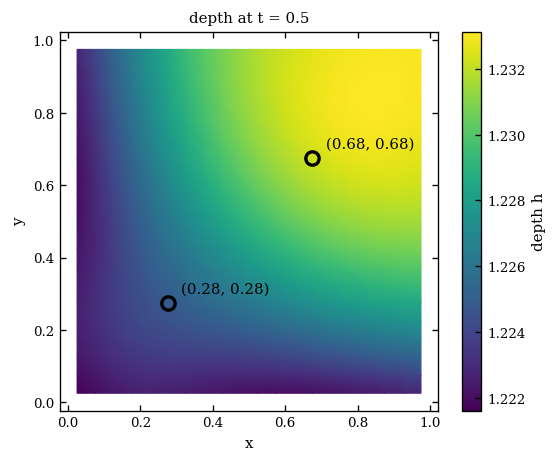

In [4]:
import matplotlib.pyplot as plt
import zoomy_plotting as zp

centers = mesh.cell_centers_computed()
x, y = centers[0][:n], centers[1][:n]

probes = [(0.30, 0.30), (0.70, 0.70)]
cells = [int(np.argmin((x - px) ** 2 + (y - py) ** 2)) for px, py in probes]

with zp.apply_style():
    fig, ax = plt.subplots(figsize=(4.8, 3.9))
    tpc = ax.tripcolor(x, y, h, shading="gouraud", cmap=zp.CMAP_CONTINUOUS)
    fig.colorbar(tpc, ax=ax, label="depth h")
    for k in cells:
        ax.plot(x[k], y[k], "o", ms=8, mfc="none", mew=2, color="k")
        ax.annotate(f"({x[k]:.2f}, {y[k]:.2f})", (x[k], y[k]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"depth at t = {solver.time_end}")
    ax.set_aspect("equal")
    fig.tight_layout()
    plt.show()

## 5. The velocity profile there

$u(\zeta) = \sum_i (q_i/h)\,\phi_i(\zeta)$, with $\zeta = 0$ the bed and
$\zeta = 1$ the free surface. The bed drag holds the flow back at the bed and
the bulk friction carries that shear upwards — a depth-averaged model
(`level=0`) is a vertical line here.

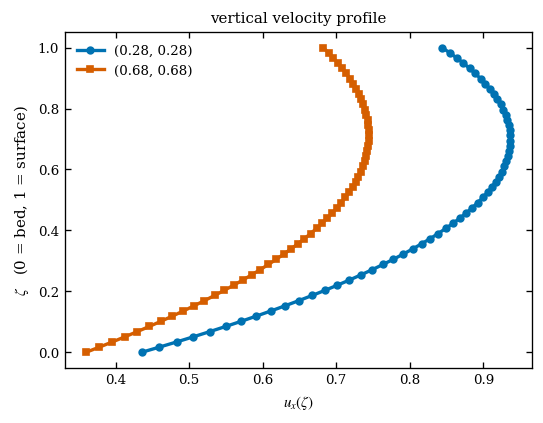

In [5]:
from zoomy_core.model.derivation.basisfunctions import Legendre_shifted

LEVEL = 2
basis = Legendre_shifted(LEVEL)
zeta = np.linspace(0.0, 1.0, 60)

with zp.apply_style():
    fig, ax = plt.subplots(figsize=(4.6, 3.6))
    for k in cells:
        alpha = [Q[2 + j][k] / h[k] for j in range(LEVEL + 1)]   # q_x_0..q_x_2
        ax.plot(basis.reconstruct_velocity_profile(alpha, N=zeta.size), zeta,
                lw=2, label=f"({x[k]:.2f}, {y[k]:.2f})")
    ax.set_xlabel(r"$u_x(\zeta)$")
    ax.set_ylabel(r"$\zeta$   (0 = bed, 1 = surface)")
    ax.set_title("vertical velocity profile")
    ax.legend()
    fig.tight_layout()
    plt.show()